# ◉ Attention Mechanism

- Reflections on Embeddings notes - [link](https://n03an.me/Embeddings.html#word-representations-in-vector-space)
- [Attention is all you need by google](https://arxiv.org/pdf/1706.03762)
- [Annotated transformers](https://nlp.seas.harvard.edu/annotated-transformer/) harvard 

![atten](./_asset/atten/1.png)

![atten](./_asset/atten/2.png)

#### 4d example

In [ ]:
import numpy as np

X = np.array([1.0, 2.0, 3.0, 4.0])
Y = np.array([1.2, 2.1, 2.9, 3.7])

def cosine_similarity(a, b):
    return np.dot(a, b) / (np.linalg.norm(a) * np.linalg.norm(b))

cos = cosine_similarity(X, Y)
angle = np.degrees(np.arccos(cos))

print("X: {}".format(X))
print("Y: {}".format(Y))
print("dot(X, Y): {:.2f}".format(np.dot(X, Y)))
print("||X||: {:.2f}".format(np.linalg.norm(X)))
print("||Y||: {:.2f}".format(np.linalg.norm(Y)))
print("cosine: {:.4f}".format(cos))
print("angle degrees: {:.2f}".format(angle))

X: [1. 2. 3. 4.]
Y: [1.2 2.1 2.9 3.7]
dot(X, Y): 28.90
||X||: 5.48
||Y||: 5.29
cosine: 0.9980
angle degrees: 3.59


#### Post normalization

In [ ]:
X_unit = X / np.linalg.norm(X)
Y_unit = Y / np.linalg.norm(Y)

print("X_unit: {}".format(np.round(X_unit, 3)))
print("Y_unit: {}".format(np.round(Y_unit, 3)))

print("dot(X_unit, Y_unit): {:.4f}".format(np.dot(X_unit, Y_unit)))
print("cosine(X_unit, Y_unit): {:.4f}".format(cosine_similarity(X_unit, Y_unit)))

X_unit: [0.183 0.365 0.548 0.73 ]
Y_unit: [0.227 0.397 0.549 0.7  ]
dot(X_unit, Y_unit): 0.9980
cosine(X_unit, Y_unit): 0.9980


![atten](./_asset/atten/3.png)

![atten](./_asset/atten/4.png)

![atten](./_asset/atten/5.png)

- [Bahdanau Attention](https://distill.pub/2016/augmented-rnns/) (2014), were specifically designed to help RNNs but...
    - The sequential bottleneck.. i.e. to compute attention for the 50th word, you must first calculate the hidden states for words 1 through 49 in order
    - Can parallelize the training due to sequential state forward architecture
    - Long term Dependency Problem i.e. for longer context the key knowledge bits would vanish

![atten](./_asset/atten/00.jpg)

### Meh...

![atten](./_asset/atten/6.jpg)

![atten](./_asset/atten/7.png)

![atten](./_asset/atten/8.png)

![atten](./_asset/atten/9.jpg)

![atten](./_asset/atten/10.jpg)

![atten](./_asset/atten/11.jpg)

![atten](./_asset/atten/12.png)

![atten](./_asset/atten/13.png)

In [51]:
import numpy as np
import matplotlib.pyplot as plt

np.set_printoptions(precision=3, suppress=True)
np.random.seed(42)

In [63]:
tokens = ["I", "prefer", "apple", "over", "orange", "because", "it", "is", "less", "acidic"]

X = np.array([
    [1.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0],  # I
    [0.0, 1.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0],  # prefer
    [0.0, 0.1, 1.0, 0.2, 0.0, 0.0, 0.1, 0.0],  # apple
    [0.0, 0.0, 0.0, 1.0, 0.0, 0.0, 0.0, 0.0],  # over
    [0.0, 0.1, 1.0, 0.2, 0.0, 0.0, 0.3, 0.0],  # orange
    [0.0, 0.0, 0.0, 0.0, 1.0, 0.0, 0.1, 0.0],  # because
    [0.0, 0.0, 0.4, 0.0, 0.0, 1.0, 0.1, 0.0],  # it
    [0.0, 0.0, 0.0, 0.0, 0.2, 0.0, 0.0, 0.0],  # is
    [0.0, 0.0, 0.0, 0.0, 0.1, 0.0, 0.4, 1.0],  # less
    [0.0, 0.0, 0.2, 0.0, 0.4, 0.0, 1.0, 0.0],  # acidic
])

print("Token embedding shape:", X.shape)

Token embedding shape: (10, 8)


In [64]:
def softmax(x, axis=-1):
    x = x - np.max(x, axis=axis, keepdims=True)
    e = np.exp(x)
    return e / np.sum(e, axis=axis, keepdims=True)


def scaled_dot_product_attention(Q, K, V):
    d_k = Q.shape[-1]
    scores = Q @ K.T / np.sqrt(d_k)
    weights = softmax(scores, axis=-1)
    output = weights @ V
    return scores, weights, output


def plot_attention_matrix(weights, tokens, title):
    plt.figure(figsize=(9, 7))
    plt.imshow(weights)
    plt.xticks(range(len(tokens)), tokens, rotation=45, ha="right")
    plt.yticks(range(len(tokens)), tokens)
    plt.colorbar(label="attention weight")
    plt.title(title)
    plt.xlabel("Key/value token being attended to")
    plt.ylabel("Query token doing the attending")

    for i in range(len(tokens)):
        for j in range(len(tokens)):
            plt.text(j, i, f"{weights[i, j]:.2f}", ha="center", va="center", fontsize=8)

    plt.tight_layout()
    plt.show()


def plot_activation(tokens, values, title, ylabel):
    plt.figure(figsize=(9, 4))
    plt.bar(tokens, values)
    plt.xticks(rotation=45, ha="right")
    plt.ylabel(ylabel)
    plt.title(title)
    plt.tight_layout()
    plt.show()

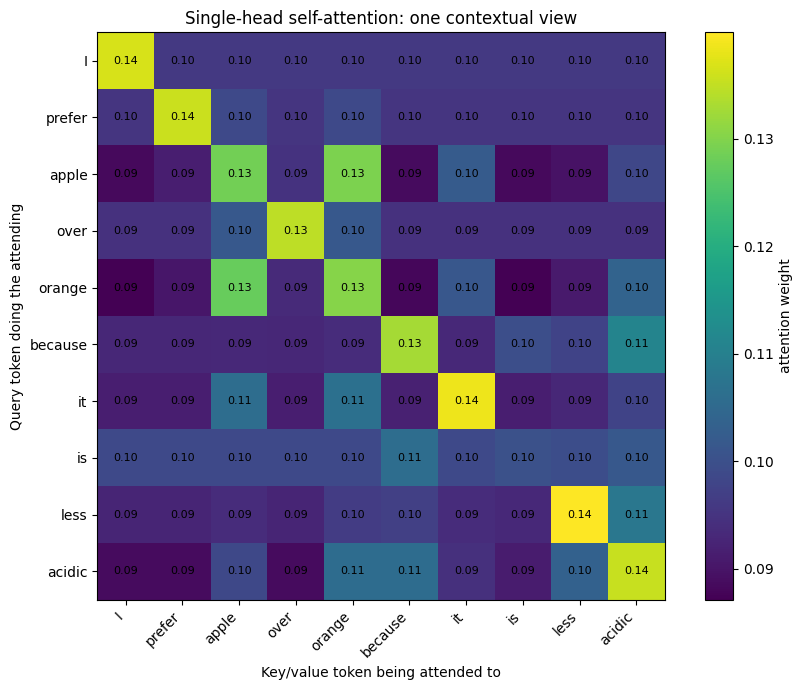

Input X shape: (10, 8)
Q shape: (10, 8)
K shape: (10, 8)
V shape: (10, 8)
Single-head output shape: (10, 8)


In [65]:
d_model = X.shape[1]

# Identity projections for teaching.
# In real transformers, Wq, Wk, Wv are learned.
Wq = np.eye(d_model)
Wk = np.eye(d_model)
Wv = np.eye(d_model)

Q = X @ Wq
K = X @ Wk
V = X @ Wv

scores, single_head_weights, single_head_output = scaled_dot_product_attention(Q, K, V)

plot_attention_matrix(
    single_head_weights,
    tokens,
    "Single-head self-attention: one contextual view"
)

print("Input X shape:", X.shape)
print("Q shape:", Q.shape)
print("K shape:", K.shape)
print("V shape:", V.shape)
print("Single-head output shape:", single_head_output.shape)

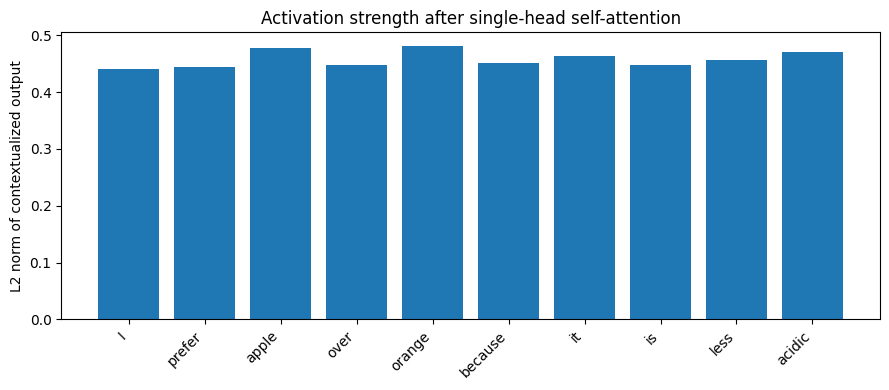

In [68]:
single_head_activation = np.linalg.norm(single_head_output, axis=1)

plot_activation(
    tokens,
    single_head_activation,
    "Activation strength after single-head self-attention",
    "L2 norm of contextualized output"
)

## Multi-head attention

![atten](./_asset/atten/14.png)

**Note**: The hard coding of various head's to focus on a specific feature is just for human explanation to visualize the attention patterns for understanding. In real models, these projections are learned automatically, and the model attention heads discovers useful patterns on its own

In [ ]:
def make_projection(selected_dims, input_dim=8):
    W = np.zeros((input_dim, len(selected_dims)))

    for out_idx, in_idx in enumerate(selected_dims):
        W[in_idx, out_idx] = 1.0

    return W


heads = {
    "Head 1: fruit/category": {
        "dims": [2],
    },
    "Head 2: preference/comparison": {
        "dims": [1, 3],
    },
    "Head 3: explanation/acidity": {
        "dims": [4, 6, 7],
    },
    "Head 4: pronoun/coreference": {
        "dims": [2, 5],
    },
}

In [71]:
head_outputs = []
head_weights = {}

for head_name, config in heads.items():
    dims = config["dims"]

    Wq = make_projection(dims, input_dim=X.shape[1])
    Wk = make_projection(dims, input_dim=X.shape[1])
    Wv = make_projection(dims, input_dim=X.shape[1])

    Q = X @ Wq
    K = X @ Wk
    V = X @ Wv

    scores, weights, output = scaled_dot_product_attention(Q, K, V)

    head_weights[head_name] = weights
    head_outputs.append(output)

    print(f"{head_name}")
    print(f"  Q/K/V shape: {Q.shape}")
    print(f"  Output shape: {output.shape}")
    print()

Head 1: fruit/category
  Q/K/V shape: (10, 1)
  Output shape: (10, 1)

Head 2: preference/comparison
  Q/K/V shape: (10, 2)
  Output shape: (10, 2)

Head 3: explanation/acidity
  Q/K/V shape: (10, 3)
  Output shape: (10, 3)

Head 4: pronoun/coreference
  Q/K/V shape: (10, 2)
  Output shape: (10, 2)



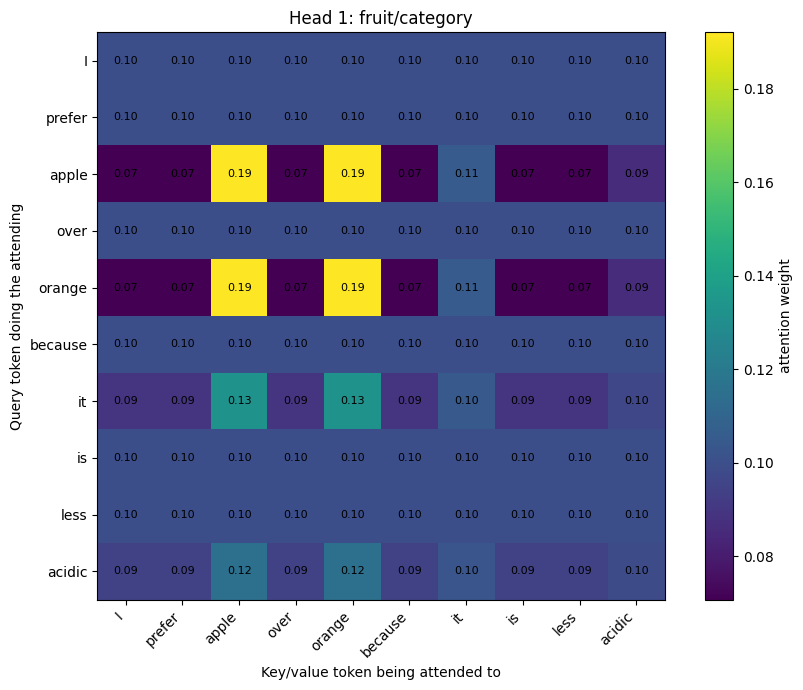

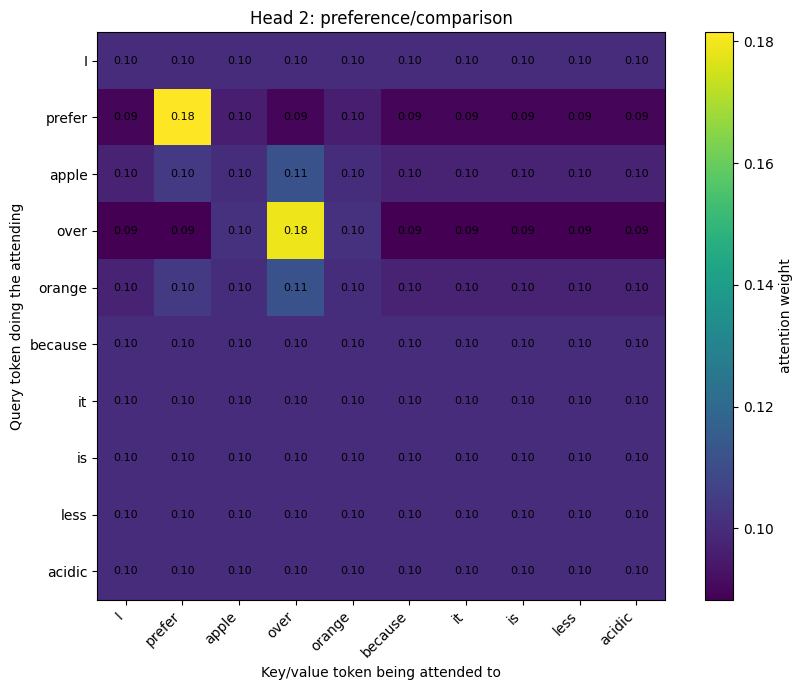

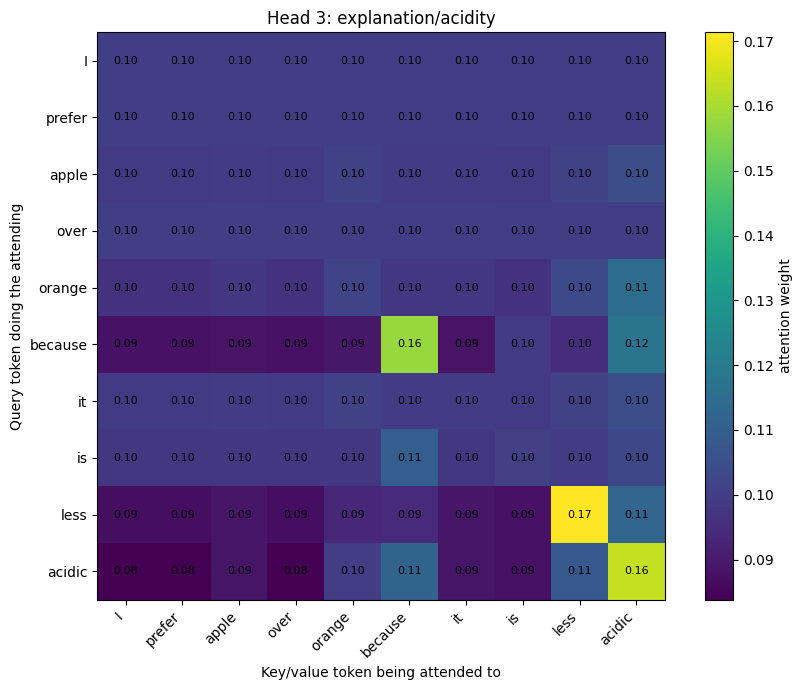

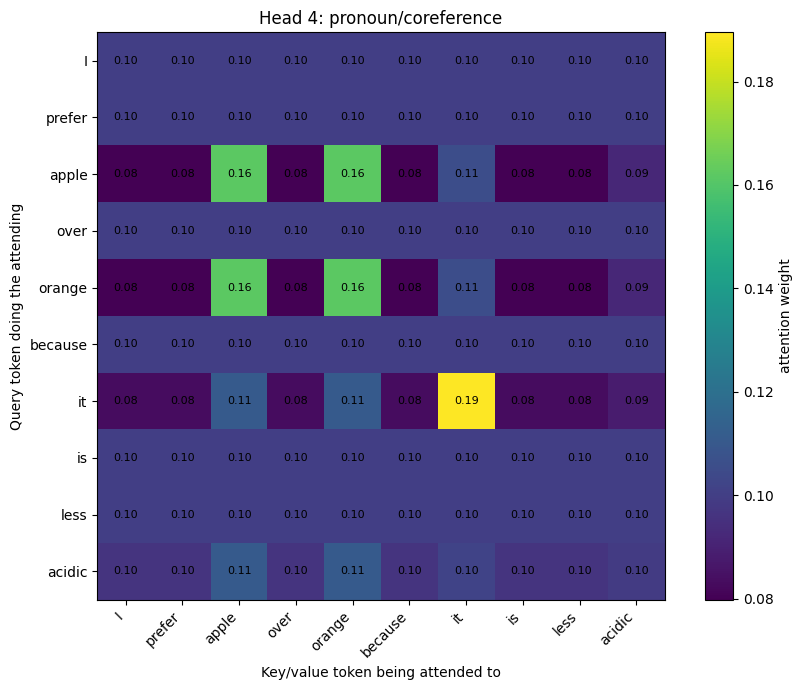

In [72]:
for head_name, weights in head_weights.items():
    plot_attention_matrix(weights, tokens, head_name)

In [59]:
multi_head_output = np.concatenate(head_outputs, axis=-1)

print("Number of heads:", len(head_outputs))
print("Single-head output shape:", single_head_output.shape)
print("Multi-head concatenated output shape:", multi_head_output.shape)

Number of heads: 4
Single-head output shape: (10, 8)
Multi-head concatenated output shape: (10, 8)


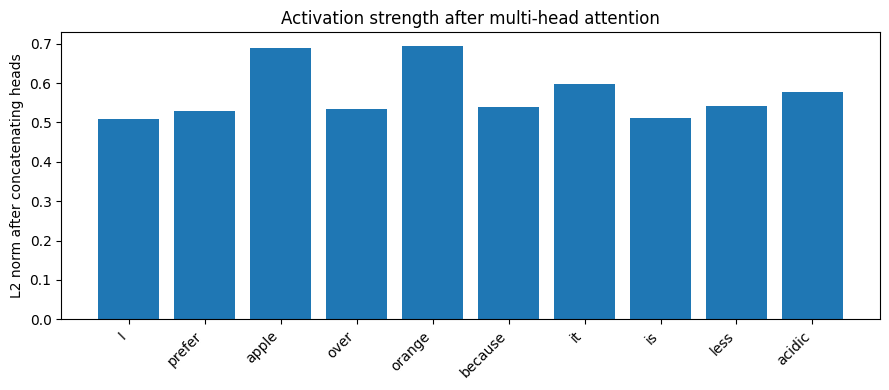

In [69]:
multi_head_activation = np.linalg.norm(multi_head_output, axis=1)

plot_activation(
    tokens,
    multi_head_activation,
    "Activation strength after multi-head attention",
    "L2 norm after concatenating heads"
)

### Comparing Self attention to Multi Head

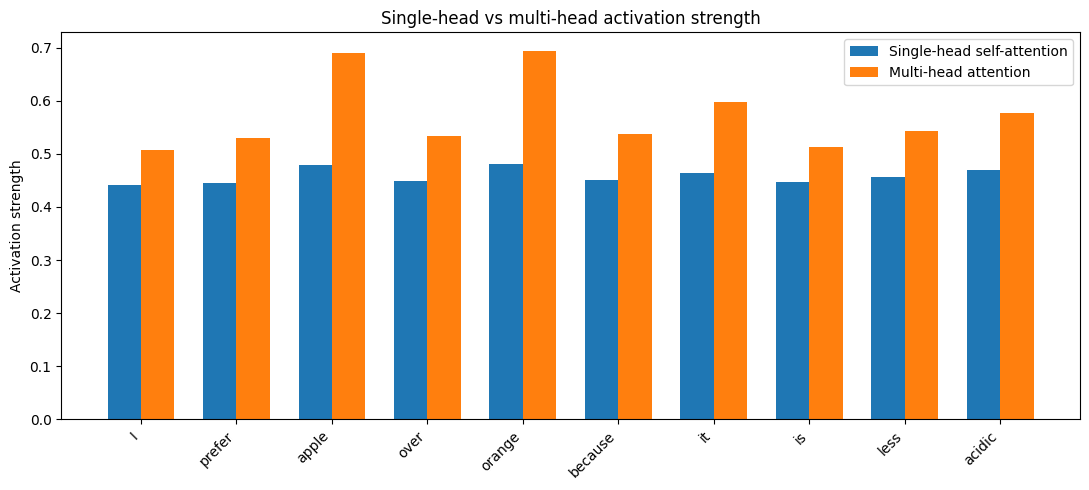

In [61]:
x = np.arange(len(tokens))
width = 0.35

plt.figure(figsize=(11, 5))

plt.bar(
    x - width / 2,
    single_head_activation,
    width,
    label="Single-head self-attention"
)

plt.bar(
    x + width / 2,
    multi_head_activation,
    width,
    label="Multi-head attention"
)

plt.xticks(x, tokens, rotation=45, ha="right")
plt.ylabel("Activation strength")
plt.title("Single-head vs multi-head activation strength")
plt.legend()
plt.tight_layout()
plt.show()